In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
df = pd.read_csv('../data/data.csv')
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [5]:
df = df.drop(columns=['id', 'Unnamed: 32'])

In [6]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [7]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

print(f"\nSetelah preprocessing:")
print(f"Fitur (X): {X.shape}")
print(f"Label (y): {y.shape}")
print(f"Distribusi diagnosis:\n{y.value_counts()}")


Setelah preprocessing:
Fitur (X): (569, 30)
Label (y): (569,)
Distribusi diagnosis:
diagnosis
0    357
1    212
Name: count, dtype: int64


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"\nSetelah standardisasi: {X_scaled.shape}")


Setelah standardisasi: (569, 30)


In [9]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained_variance = pca.explained_variance_ratio_

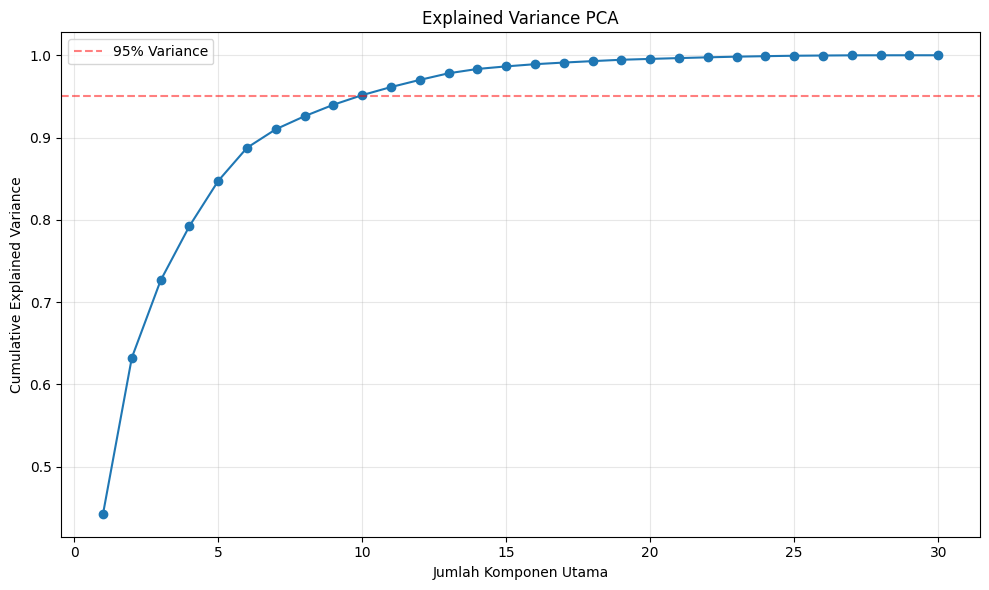

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance)+1), np.cumsum(explained_variance), marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', alpha=0.5, label='95% Variance')
plt.xlabel('Jumlah Komponen Utama')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance PCA')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [11]:
# Tampilkan variance untuk beberapa komponen pertama
print("\nExplained Variance untuk 10 komponen pertama:")
for i, var in enumerate(explained_variance[:10], 1):
    print(f"PC{i}: {var:.4f} ({np.cumsum(explained_variance)[i-1]:.4f} cumulative)")

# Tentukan jumlah komponen untuk mencapai 95% variance
n_components_95 = np.argmax(np.cumsum(explained_variance) >= 0.95) + 1
print(f"\nJumlah komponen untuk 95% variance: {n_components_95}")


Explained Variance untuk 10 komponen pertama:
PC1: 0.4427 (0.4427 cumulative)
PC2: 0.1897 (0.6324 cumulative)
PC3: 0.0939 (0.7264 cumulative)
PC4: 0.0660 (0.7924 cumulative)
PC5: 0.0550 (0.8473 cumulative)
PC6: 0.0402 (0.8876 cumulative)
PC7: 0.0225 (0.9101 cumulative)
PC8: 0.0159 (0.9260 cumulative)
PC9: 0.0139 (0.9399 cumulative)
PC10: 0.0117 (0.9516 cumulative)

Jumlah komponen untuk 95% variance: 10


In [12]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

In [13]:
df_pca = pd.DataFrame({
    'PC1': X_pca_2[:, 0],
    'PC2': X_pca_2[:, 1],
    'diagnosis': y
})

print(f"\nPCA dengan 2 komponen: {X_pca_2.shape}")
print(f"Explained variance dengan 2 komponen: {sum(pca_2.explained_variance_ratio_):.4f}")


PCA dengan 2 komponen: (569, 2)
Explained variance dengan 2 komponen: 0.6324


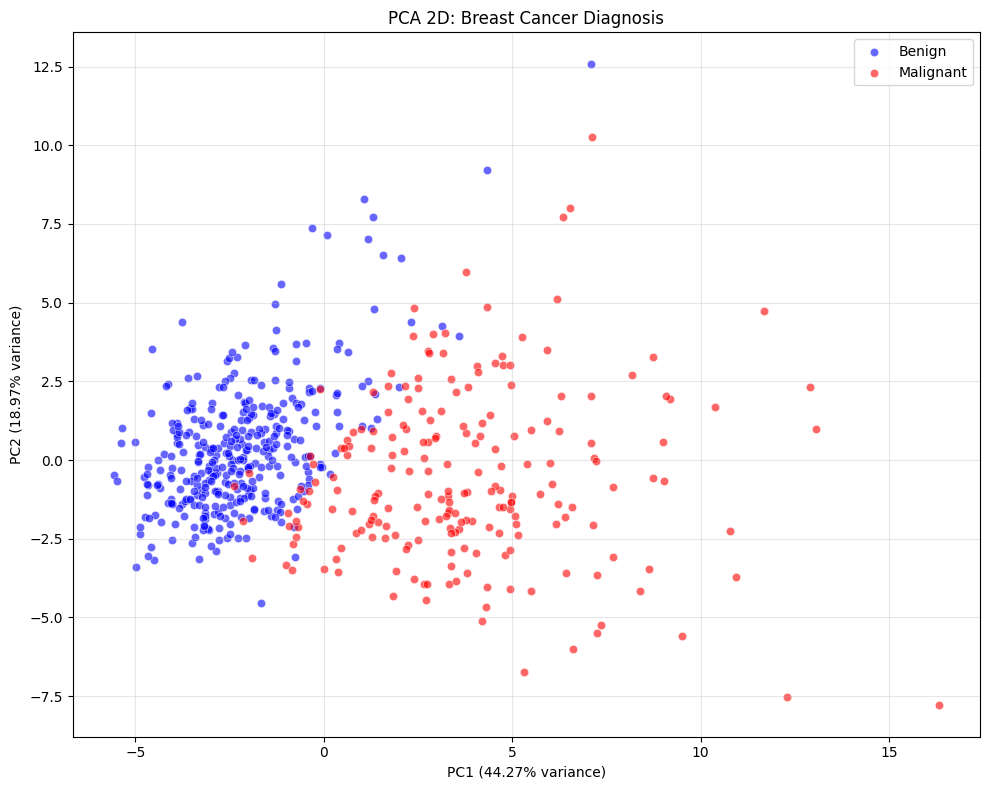

In [14]:
plt.figure(figsize=(10, 8))

# Plot berdasarkan diagnosis
for diagnosis_value, color, label in [(0, 'blue', 'Benign'), (1, 'red', 'Malignant')]:
    mask = df_pca['diagnosis'] == diagnosis_value
    plt.scatter(
        df_pca.loc[mask, 'PC1'], 
        df_pca.loc[mask, 'PC2'],
        c=color, 
        alpha=0.6, 
        edgecolors='w', 
        linewidth=0.5,
        label=label
    )

plt.xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]:.2%} variance)')
plt.title('PCA 2D: Breast Cancer Diagnosis')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
print("\n" + "="*50)
print("RINGKASAN ANALISIS PCA")
print("="*50)
print(f"1. Dataset awal: {df.shape[0]} sampel, {df.shape[1]} fitur")
print(f"2. Setelah preprocessing: {X.shape[1]} fitur numerik")
print(f"3. Variance explained dengan 2 komponen: {sum(pca_2.explained_variance_ratio_):.2%}")
print(f"4. Komponen untuk 95% variance: {n_components_95}")
print(f"5. Pemisahan data berdasarkan diagnosis terlihat jelas pada visualisasi 2D")


RINGKASAN ANALISIS PCA
1. Dataset awal: 569 sampel, 31 fitur
2. Setelah preprocessing: 30 fitur numerik
3. Variance explained dengan 2 komponen: 63.24%
4. Komponen untuk 95% variance: 10
5. Pemisahan data berdasarkan diagnosis terlihat jelas pada visualisasi 2D
